In [15]:
import pandas as pd
import numpy as np
import re
import sys
import subprocess
import matplotlib.pyplot as plt
from matplotlib import rcParams
import seaborn as sns
from scipy import stats

rcParams['font.family'] = 'Arial'

## Utils

In [16]:
dict_assembly_species = {
    'mGorGor1': 'Gorilla',
    'gorGor6': 'Gorilla',
    'mPanPan1': 'Bonobo',
    'panPan3': 'Bonobo',
    'mPanTro3': 'Chimpanzee',
    'panTro6': 'Chimpanzee',
    'mPonAbe1': 'Sumatran orangutan',  # Sumatran Orangutan
    'ponAbe3': 'Sumatran orangutan',   # Sumatran Orangutan
    'mPonPyg2': 'Bornean orangutan',  # Bornean Orangutan
    'mSymSyn1':'Siamang',
    'CHM13': 'Human',
    'GRCh38': 'Human'
}


def sort_hsa(df_in):
    '''
    Sort HSA column in plotting order.
    '''
    df = df_in.copy()
    # Index for HSA.
    dict_hsa = {
        'hsa1':1, 'hsa2':2, 'hsa3':3, 'hsa4':4, 'hsa5':5, 'hsa6':6, 'hsa7':7, 'hsa8':8, 'hsa9':9, 'hsa10':10, 'hsa11':11, 'hsa12':12, 'hsa13':13, 'hsa14':14, 'hsa15':15, 'hsa16':16, 'hsa17':17, 'hsa18':18, 'hsa19':19, 'hsa20':20, 'hsa21':21, 'hsa22':22, 'hsa23':23, 'hsa24':24, 'hsaX':30, 'hsaY':31, 'hsa17x5':4, 'hsa5x17':19, 'hsa2a':2, 'hsa2b':2.7, 'hsa2A':2, 'hsa2B':2.5,
        'chr1':1, 'chr2':2, 'chr2A':2, 'chr2a':2, 'chr2B':2.7, 'chr2b':2.7, 'chr3':3, 'chr4':4, 'chr5':5, 'chr6':6, 'chr7':7, 'chr8':8, 'chr9':9, 'chr10':10, 'chr11':11, 'chr12':12, 'chr12_relab':12, 'chr13':13, 'chr14':14, 'chr15':15, 'chr16':16, 'chr17':17, 'chr18':18, 'chr19':19, 'chr19_relab':19, 'chr20':20, 'chr21':21, 'chr22':22, 'chr23':23, 'chr24':24, 'chrX':30, 'chrY':31
        }
    dict_hsa = {
        '1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6, '7': 7, '8': 8, 
        '9': 9, '10': 10, '11': 11, '12': 12, '13': 13, '14': 14, 
        '15': 15, '16': 16, '17': 17, '18': 18, '19': 19, '20': 20, 
        '21': 21, '22': 22, '23': 23, '24': 24, 'X': 30, 'Y': 31,
        '2A': 3, '2B': 3, '17x5': 28, '5x17': 29, '2a': 3, '2b': 3,
        '12_relab': 12, '19_relab': 19
        }

    df['index_HSA'] = df['HSA'].map(dict_hsa).fillna('MISSING')
    if df[df['index_HSA']=='MISSING'].shape[0] > 0:
        print('Missing: ',df[df['index_HSA']=='MISSING'].shape[0])
        return df[df['index_HSA']=='MISSING']
        sys.exit(f'### Missing values in HSA column ###')
    return df.sort_values('index_HSA')


colorblind_friendly_palette = {
    "Black": "#000000",
    "Orange": "#F4A637",
    "Light blue": "#B6DBFF",
    "Vermilion": "#DB5829",
    "Mid blue": "#7BB0DF",
    "Maroon": "#894B45",
    "Dark blue": "#1964B0",
    "Light purple": "#D2BBD7",
    "Light teal": "#00C992",
    "Purple": "#AE75A2",
    "Teal": "#008A69",
    "Dark purple": "#882D71",
    "Dark teal": "#386350",
    "Grey": "#DEDEDE",
    "Yellow": "#E9DC6D"
}

palette7 = ["#005f73", "#0a9396", "#94d2bd", "#e9d8a6", "#ca6702", "#9b2226", "#450000" ] #subset of 6 colors from coolor.co set of 10, colorblind tested in chroma.js  #Added an extra at the end for Siamang


## Parameters

In [17]:
NUMT_DIR="../numts_from_laptop_blast/numt_set"
CHROM_SIZE_DIR="../numts_from_laptop_blast/chrom_sizes"

## Import NUMTs

In [18]:
assemblies=['mGorGor1', 'gorGor6', 'mPanPan1', 'panPan3', 'mPanTro3', 'panTro6', 'mPonAbe1', 'ponAbe3', 'mPonPyg2', 'CHM13', 'GRCh38', 'mSymSyn1']
t2t_assemblies = [ "mPanPan1", "mPanTro3", "CHM13", "mGorGor1", "mPonAbe1", "mPonPyg2", "mSymSyn1" ]

def get_numts(haplotype="pri", sex=False):

    if haplotype not in ["pri","alt"]:
        raise ValueError("# Do not recognize haplotype. Must be <pri> or <alt>")
        
    list_dfs=[]
    for assembly in t2t_assemblies:
        if assembly == 'CHM13':
            if haplotype == "pri":
                file_in = f"{NUMT_DIR}/numts.{assembly}.pri.bed" #NUMTs V2
            else:
                continue
        else:
            file_in = f"{NUMT_DIR}/numts.{assembly}.{haplotype}.bed" #NUMTs V2
        bed_headers = ['Chrom','Start','End','Name','Score','Strand','NUMT_ID']
        # Import BED file.
        df = pd.read_table( file_in, header=None, names=bed_headers )
        # Annotate.
        df['Assembly'] = assembly
        df['Haplotype'] = haplotype
        df['Species'] = df['Assembly'].map(dict_assembly_species)
        df['Species_Chrom'] = df['Chrom'].str.split('_').str[0]
        df['HSA'] = df['Chrom'].str.split('_').str[2].fillna(df['Species_Chrom'])
        #df.loc[ df['Assembly']=='mSymSyn1', 'HSA' ] = 'Does_not_apply' #Siamang does not have HSA
        df.loc[ df['Assembly']=='CHM13', 'HSA' ] = df['Chrom'] #Human has NC IDs
        df.loc[ df['Assembly']=='CHM13', 'Species_Chrom' ] = df['Chrom'] #Human has NC IDs
        df['Species_Chrom'] = df['Species_Chrom'].str.split('chr').str[-1]
        df['HSA'] = df['HSA'].str.split('hsa').str[-1].str.split('chr').str[-1]
        # Compute length of each NUMT.
        df['NUMT_Length'] = df['End'] - df['Start']
        list_dfs.append(df)
    df = pd.concat(list_dfs).drop_duplicates()
    # Reset the index (if necessary).
    df = df.reset_index(drop=True)
    # Split human chromosome 2.
    df = adjust_chromosome_labels(df)

    # Exclude sex chromosomes.
    if sex == False:
        df = df[(~df['Chrom'].str.contains('chrX'))&(~df['Chrom'].str.contains('chrY'))]

    # Output.
    return df#[['Assembly','HSA','Species_Chrom']].drop_duplicates()


def adjust_chromosome_labels(df):
    # CHM13 centromere data for chromosome 2
    # midpoint_centromere_chr2_chm13 = 93500000
    site_of_fusion_chr2_chm13 = 114000000
    size_chr2_chm13 = 242696752
    human_2_to_2a = [0, site_of_fusion_chr2_chm13 - 1]
    human_2_to_2b = [site_of_fusion_chr2_chm13, size_chr2_chm13]

    # Update 'Chrom' column based on position relative to the centromere
    df.loc[
        (df['Assembly'] == 'CHM13') & (df['Species_Chrom'] == '2') & (df['Start'] < site_of_fusion_chr2_chm13),
        'Chrom'
    ] = 'chr2a'
    
    df.loc[
        (df['Assembly'] == 'CHM13') & (df['Species_Chrom'] == '2') & (df['Start'] > site_of_fusion_chr2_chm13),
        'Chrom'
    ] = 'chr2b'

    # Create or update 'HSA' column to remove the 'chr' prefix from 'Chrom' values
    df.loc[df['Assembly'] == 'CHM13', 'HSA'] = df['Chrom'].str.split('chr').str[-1]
    # Output.
    return df


# numts = get_numts(haplotype="pri", sex=False)
# numts

## Import Chromosome Sizes

In [19]:
def get_chrom_sizes():
    list_dfs=[]
    for assembly in t2t_assemblies:
        if assembly == 'CHM13':
            file_name = f"{CHROM_SIZE_DIR}/{assembly}.fai"
        else:
            file_name = f"{CHROM_SIZE_DIR}/{assembly}.bothHaps.fai" #includes both haplotypes
        fai_headers=['Chrom','Chrom_Size',59,60,61] 
        df = pd.read_table( file_name, header=None, names=fai_headers)
        df['Assembly'] = assembly
        list_dfs.append(df)
    df = pd.concat(list_dfs).drop([59,60,61],axis=1)
    # Add split human chr2 into chr2a and chr2b.
    midpoint_centromere_chr2_chm13 = 93500000
    size_chr2_chm13 = 242696752
    human_chr2a2b = pd.DataFrame([
        ['chr2a', midpoint_centromere_chr2_chm13, 'CHM13'],
        ['chr2b', size_chr2_chm13 - midpoint_centromere_chr2_chm13, 'CHM13'],
    ], columns=['Chrom','Chrom_Size','Assembly'])
    df = pd.concat( [df, human_chr2a2b] )
    # Output.
    return df
        

# get_chrom_sizes()

## Compute NUMT abundance by chromosome

In [20]:
def compute_total_numt_bp_by_chr(df_in, excl_second_contigs=True, write=False):
    df = df_in.copy()
    df = df[['Species','Assembly','Haplotype','Chrom','Species_Chrom','HSA','Start','End']].drop_duplicates()
    # Exclude Y-chr.
    df = df[df['Species_Chrom']!='chrY']
    # Categorize assemblies.
    df['Version'] = 'non-T2T'
    df.loc[df['Assembly'].str[0]=='m','Version'] = 'T2T'
    df.loc[df['Assembly']=='CHM13','Version'] = 'T2T'
    # Length of each NUMT.
    df['Length'] = abs(df['End'] - df['Start'] + 1)
    # Counts of NUMTs by species.
    df_abundance = df.value_counts(['Species','Version','Assembly','Haplotype','Chrom','Species_Chrom','HSA']).reset_index().rename(columns={0:'NUMT_Counts','count':'NUMT_Counts'})
    # Sum of NUMT lengths.
    df_totalbp = df.groupby(['Species','Version','Assembly','Haplotype','Chrom','Species_Chrom','HSA'])['Length'].sum().reset_index().rename(columns={'Length':'Total_bp'})
    df = pd.merge( df_abundance, df_totalbp )
    # Numts as percentage of genome.
    df_chrom_sizes = get_chrom_sizes() #chrom sizes per species assembly.
    df = pd.merge( df, df_chrom_sizes )
    df = df.assign(Perc_chrom=100*df['Total_bp']/df['Chrom_Size']) #percentage of genome covered by NUMTs.
    df = df.sort_values(['Species_Chrom','Species'])
    # Normalize NUMT events and total NUMT length (bp) by chromosome size (bp).
    df['Density_of_bp'] = df['Total_bp'] / df['Chrom_Size']
    df['Density_of_events'] = df['NUMT_Counts'] / df['Chrom_Size']
    # # Switches labels for Siamang chr12 and chr19.
    # df = relabel_siamang_chr(df)
    # Export as table.
    if write == True:
        df.to_csv(f"abundance_Numts_byChromosome.table", index=None, sep='\t')
    return df.drop_duplicates()

# numts_summary = compute_total_numt_bp_by_chr(df_in=numts, write=True)
# numts_summary

numts_pri = compute_total_numt_bp_by_chr(df_in=get_numts("pri"), write=False)
numts_alt = compute_total_numt_bp_by_chr(df_in=get_numts("alt"), write=False)

numts = pd.concat([numts_pri,numts_alt])
numts.groupby(['Assembly','Haplotype'])['NUMT_Counts'].sum().reset_index().sort_values(['Haplotype'], ascending=False)


,Assembly,Haplotype,NUMT_Counts
0,CHM13,pri,711
2,mGorGor1,pri,648
4,mPanPan1,pri,713
6,mPanTro3,pri,717
8,mPonAbe1,pri,715
10,mPonPyg2,pri,714
12,mSymSyn1,pri,559
1,mGorGor1,alt,656
3,mPanPan1,alt,702
5,mPanTro3,alt,723


## Histogram NUMT Lengths

In [21]:
def plot_lengths(df_in, font_sizes=None, ax=None):
    # Import data.
    df = df_in
    
    # Reorder columns and change orangutan names.
    df = df[['Species', 'Assembly', 'Haplotype', 'Chrom', 'Start', 'End', 'NUMT_Length']]
    df = df.replace({'Sumatran orangutan': 'S. orangutan', 'Bornean orangutan': 'B. orangutan'})
    
        # Set the color palette
    # colors = ['Dark blue', 'Light blue', 'Light teal', 'Purple', 'Yellow', 'Vermilion', 'Grey']
    colors = ['Dark blue', 'Mid blue', 'Dark purple', 'Grey', 'Light teal', 'Teal', 'Yellow' ]
    palette = [colorblind_friendly_palette[color] for color in colors ]
    palette = palette7[:6]
    species_order = ['Bonobo','Chimpanzee','Human','Gorilla','B. orangutan','S. orangutan']
    # Create a dictionary of colors and species order
    colors_dict = {species: color for species, color in zip(species_order, palette)}

    # Create a KDE distribution plot.    
    ax = sns.kdeplot( ax=ax,
        data=df, bw_adjust=1,log_scale=True, linewidth=3,
        x='NUMT_Length', 
        hue='Species', hue_order = species_order, palette=palette,
    )

    # Font sizes.
    tick_label = font_sizes['tick_label'] if font_sizes else 20
    axis_label = font_sizes['axis_label'] if font_sizes else 25
    legend_size = font_sizes['legend'] if font_sizes else 15
    rotation_axis_label = font_sizes['rotation_axis_label'] if font_sizes else 25
    
    # Increase text sizes.
    ax.set_xlabel('NUMT length (bp)', fontsize=axis_label)  # X-axis label
    ax.set_ylabel('Proportion', fontsize=axis_label)  # Y-axis label
    ax.tick_params(axis='both', labelsize=tick_label)  # Adjust tick label size here

    # Add median NUMT length for each species as a vertical line
    medians = df.groupby('Species')['NUMT_Length'].median()
    # for species, median in medians.items():
    #     ax.axvline(median, linewidth=2, label=f'{species} median', color=colors_dict[species])
    #     ax.text(median, ax.get_ylim()[1] * (0.9 - 0.1 * species_order.index(species)), f'{median:.0f}', color=colors_dict[species], ha='center', va='center', fontsize=legend_size, rotation=45)
    print(medians)

    # Customize the legend
    sns.move_legend(ax, "best", frameon=False, fontsize=legend_size, title='')


# # Call the function
# plot_lengths(df_in=numts)


## Bar-plot | NUMT stats by chromosome 

In [22]:
def plot_by_chr(
        df_in, y_column='Density_of_bp', font_sizes=None, ax=None
    ):
    df = df_in.copy()
    list_assemblies = ['mPanPan1','mPanTro3','CHM13','mGorGor1','mPonAbe1','mPonPyg2']
    df = df[df['Assembly'].isin(list_assemblies)]
    df = sort_hsa(df)
    # # Change 17x5 and 5x17 labels to be lower in the plot.
    # df = df.replace({'17x5':'\n17x5','5x17':'\n\n5x17'})
    # Rename species.
    df['Species'] = df['Species'].replace({'Sumatran orangutan':'S. orangutan', 'Bornean orangutan':'B. orangutan'})
    # Plot.
    if y_column == 'NUMT_Counts':
        y_label = 'Number of NUMTs'
    elif y_column == 'Density_of_events':
        y_label = 'Number of NUMTs per total NUMT bp'
    elif y_column == 'Total_bp':
        y_label = 'NUMT content (kb)'
        df[y_column] = df[y_column]/1000
    elif y_column == 'Density_of_bp':
        y_label = 'Fraction of total NUMT bp'
    else:
        y_label = y_column
    # Plot order of species.
    species_order = ['Bonobo','Chimpanzee','Human','Gorilla','B. orangutan','S. orangutan']
    # Palettes
    colors = ['Dark blue', 'Mid blue', 'Dark purple', 'Yellow', 'Light teal', 'Teal' ]
    # colors = ['Dark blue', 'Mid blue', 'Dark purple', 'Light purple', 'Dark teal', 'Light teal' ]
    # colors = [ 'Vermilion' ,'Mid blue', 'Teal', 'Orange', 'Purple', 'Grey' ]
    palette = [ colorblind_friendly_palette[color] for color in colors ]
    # palette = ['#a6cee3','#1f78b4','#b2df8a','#33a02c','#fb9a99','#e31a1c','#fdbf6f']
    # palette = reversed( ['#d73027','#fc8d59','#fee090','#e0f3f8','#91bfdb','#4575b4'] ) #colorbrewer blue to red
    palette = palette7[:6]
    
    # Plot
    sns.barplot( ax=ax,
        data = df.sort_values('index_HSA', ascending=True), x = 'HSA', y = y_column, hue = 'Species',
        hue_order = species_order,
        palette = palette, width=0.7, edgecolor='black', linewidth=0.8, alpha=1,
    )
    # Add y empty space by adjusting the y-axis limits
    max_value = df[ y_column ].max()
    ax.set_ylim(0, max_value + max_value * 0.1)  # Add 10% space above the max value

    # Font sizes.
    tick_label = font_sizes['tick_label'] if font_sizes else 20
    axis_label = font_sizes['axis_label'] if font_sizes else 25
    legend_size = font_sizes['legend'] if font_sizes else 15
    rotation_axis_label = font_sizes['rotation_axis_label'] if font_sizes else 25

    # Increase text sizes
    ax.legend(loc='best',fontsize=legend_size, bbox_to_anchor=(1,1), markerscale=1.5, edgecolor='white')
    haplotype = df['Haplotype'].unique()[0]
    ax.set_xlabel(f'Homologous chromosomes', fontsize=axis_label)  # X-axis label
    ax.set_ylabel ( y_label , fontsize=axis_label)    # Y-axis label
    ax.tick_params(axis='both', labelsize=tick_label)  # Adjust tick label size here
    ax.tick_params(axis='x', rotation=rotation_axis_label)
    
#%tb
# plot_by_chr(df_in=numts_summary, y_column='NUMT_Counts')
# plot_by_chr(df_in=numts_summary, y_column='Total_bp')

## Heatmap | NUMT density by species and chromosome

In [23]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable

def create_custom_cmap(cmap='YlGnBu'):
    # Get the base colors from "YlGnBu".
    base_cmap = plt.get_cmap(cmap)

    # Fraction of bins in the custom map that will have a wide range of colors (0-1).
    fraction_of_bins = 0.5
    
    # Fraction that determines how wide the range of colors will be in the first half (0-1).
    fraction_base_cmap = 0.8
    
    # Sample the first half (or fraction) of color map.
    bins_first_half = int( 256 * fraction_of_bins )
    first_half_colors = base_cmap(np.linspace(0, fraction_base_cmap, bins_first_half))  # Adjust this range for compression
    
    # Second half (or fraction) of color map - Fill with darkest blue
    bins_second_half = 256 - bins_first_half
    second_half_colors = base_cmap(np.linspace(fraction_base_cmap, 1, bins_second_half))  # Adjust this range for compression
    
    # Combine both halves
    combined_colors = np.vstack((first_half_colors, second_half_colors))
    
    # Create the custom colormap
    return LinearSegmentedColormap.from_list("CustomYlGnBu", combined_colors)

# Create the custom colormap
# custom_cmap = create_custom_cmap()


def plot_density_heat(
        df_in, chrom_column='HSA', data_column='Density_of_events', exclude_y=False, skewed_cmap=False, show_values=False, font_sizes=None, ax=None
    ):
    '''
    Heatmap of NUMT density (total_bp/chrom_size) for each species and chromosome.
    Can be changed to visualize NUMT events/bp.
    '''
    df = df_in.copy()
    haplotype = df_in['Haplotype'].unique()[0]

    # Keep T2T assemblies.
    list_assemblies = ['mPanPan1','mPanTro3','CHM13','mGorGor1','mPonAbe1','mPonPyg2']
    if haplotype == 'alt':
        list_assemblies = ['mPanPan1','mPanTro3','mGorGor1','mPonAbe1','mPonPyg2']
    df = df[df['Assembly'].isin(list_assemblies)]

    # Rename species.
    df['Species'] = df['Species'].replace({'Sumatran orangutan':'S. orangutan', 'Bornean orangutan':'B. orangutan'})

    # Change the scale of density values by the order of magnitude of the max value.
    exponent = abs(int(np.floor(np.log10(np.max(df[data_column])))))
    df[data_column] = df[data_column] * 10 ** exponent

    # Turn into 2D matrix.
    df = df[['Species',chrom_column,data_column]].pivot_table(values=data_column,index='Species',columns=chrom_column)

    # Reorder chromosome columns.
    if 'X' in df.columns and 'Y' in df.columns:
        df = df[ ['1','2a','2b'] + [str(x) for x in range(3,23)] + ['17x5','5x17','X','Y'] ]
    else:
        df = df[ ['1','2a','2b'] + [str(x) for x in range(3,23)] + ['17x5','5x17'] ]

    # If haplotype is "alt", make Human white
    if haplotype == 'alt':
        df.loc['Human'] = np.nan

    # Species order.
    df = df.reindex(index=['Bonobo','Chimpanzee','Human','Gorilla','B. orangutan','S. orangutan'])

    # # Change 17x5 and 5x17 labels to be lower in the plot.
    # df = df.rename(columns={'17x5':'\n17x5','5x17':'\n\n5x17'})
    
    # Seaborn parameters.
    cmap = plt.get_cmap('crest') #sequential palette
    cmap = plt.get_cmap('flare') #sequential palette
    cmap = plt.get_cmap('YlGnBu') #sequential palette
    if skewed_cmap:
        cmap = create_custom_cmap('YlGnBu')
    else:
        cmap = plt.get_cmap('YlGnBu')

    # Color of blocks without a value.
    cmap.set_bad('white')

    if data_column == 'Density_of_events':
        cbar_title = f'\nNUMTs per bp'
        title = f'$10^{{-{exponent}}}$'
    elif data_column == 'Density_of_bp':
        cbar_title = f'\nFraction of\ntotal NUMT length'
        title = f'$10^{{-{exponent}}}$'
    else:
        title = data_column
    
    #########
    # Flip heatmap.
    # df = df.transpose()
    # Plot HEATMAP.
    heatmap = sns.heatmap( ax=ax,
        data=df, cmap=cmap, linecolor="white", linewidth=1, annot=show_values, annot_kws={"size": 12,"shrink": 0.1}, cbar=False
        )
    
    # Font sizes.
    tick_label = font_sizes['tick_label'] if font_sizes else 20
    axis_label = font_sizes['axis_label'] if font_sizes else 25
    rotation_axis_label = font_sizes['rotation_axis_label'] if font_sizes else 25

    # Increase text sizes
    ax.set_ylabel('', fontsize=axis_label)
    # plt.xlabel(f'Chromosome ({haplotype})', fontsize=axis_label)
    ax.set_xlabel('Homologous chromosomes', fontsize=axis_label)
    ax.tick_params(axis='both', labelsize=tick_label)  # Adjust tick label size here
    ax.tick_params(axis='x', rotation=rotation_axis_label)
    # ax.set_title( title, loc="right", fontsize=20, x=1.04 )

    # Create a divider for the existing axes instance
    divider = make_axes_locatable(ax)
    
    # Create a new axis for the color bar
    cax = divider.append_axes("right", size="2%", pad=0.5)
    
    # Manually add the color bar
    cbar = plt.colorbar(heatmap.collections[0], cax=cax, orientation='vertical')

    # Customize the color bar (legend) font size
    cbar = heatmap.collections[0].colorbar
    cbar.ax.tick_params(labelsize=tick_label)  # Set font size of color bar ticks
    cbar.set_label(cbar_title, fontsize=axis_label)  # Set colorbar label size
    # Add a small title on top of the color bar
    cbar_title_text = cax.text(0.7, 1.05, title, ha='center', va='center', fontsize=tick_label, transform=cax.transAxes)
    # cbar.set_label(f'{title}', fontsize=20, fontdict={'fontname': 'Arial'}, rotation=270)  # Customize color bar label


# plot_density_heat(df_in=numts_summary, data_column='Density_of_events', exclude_y=False, skewed_cmap=True, show_values=False)
# plot_density_heat(df_in=numts_summary, data_column='Density_of_bp', exclude_y=False, skewed_cmap=True, show_values=False)


# Subplots

Species
B. orangutan    279.0
Bonobo          299.0
Chimpanzee      280.0
Gorilla         265.0
Human           275.0
S. orangutan    273.0
Siamang         264.0
Name: NUMT_Length, dtype: float64


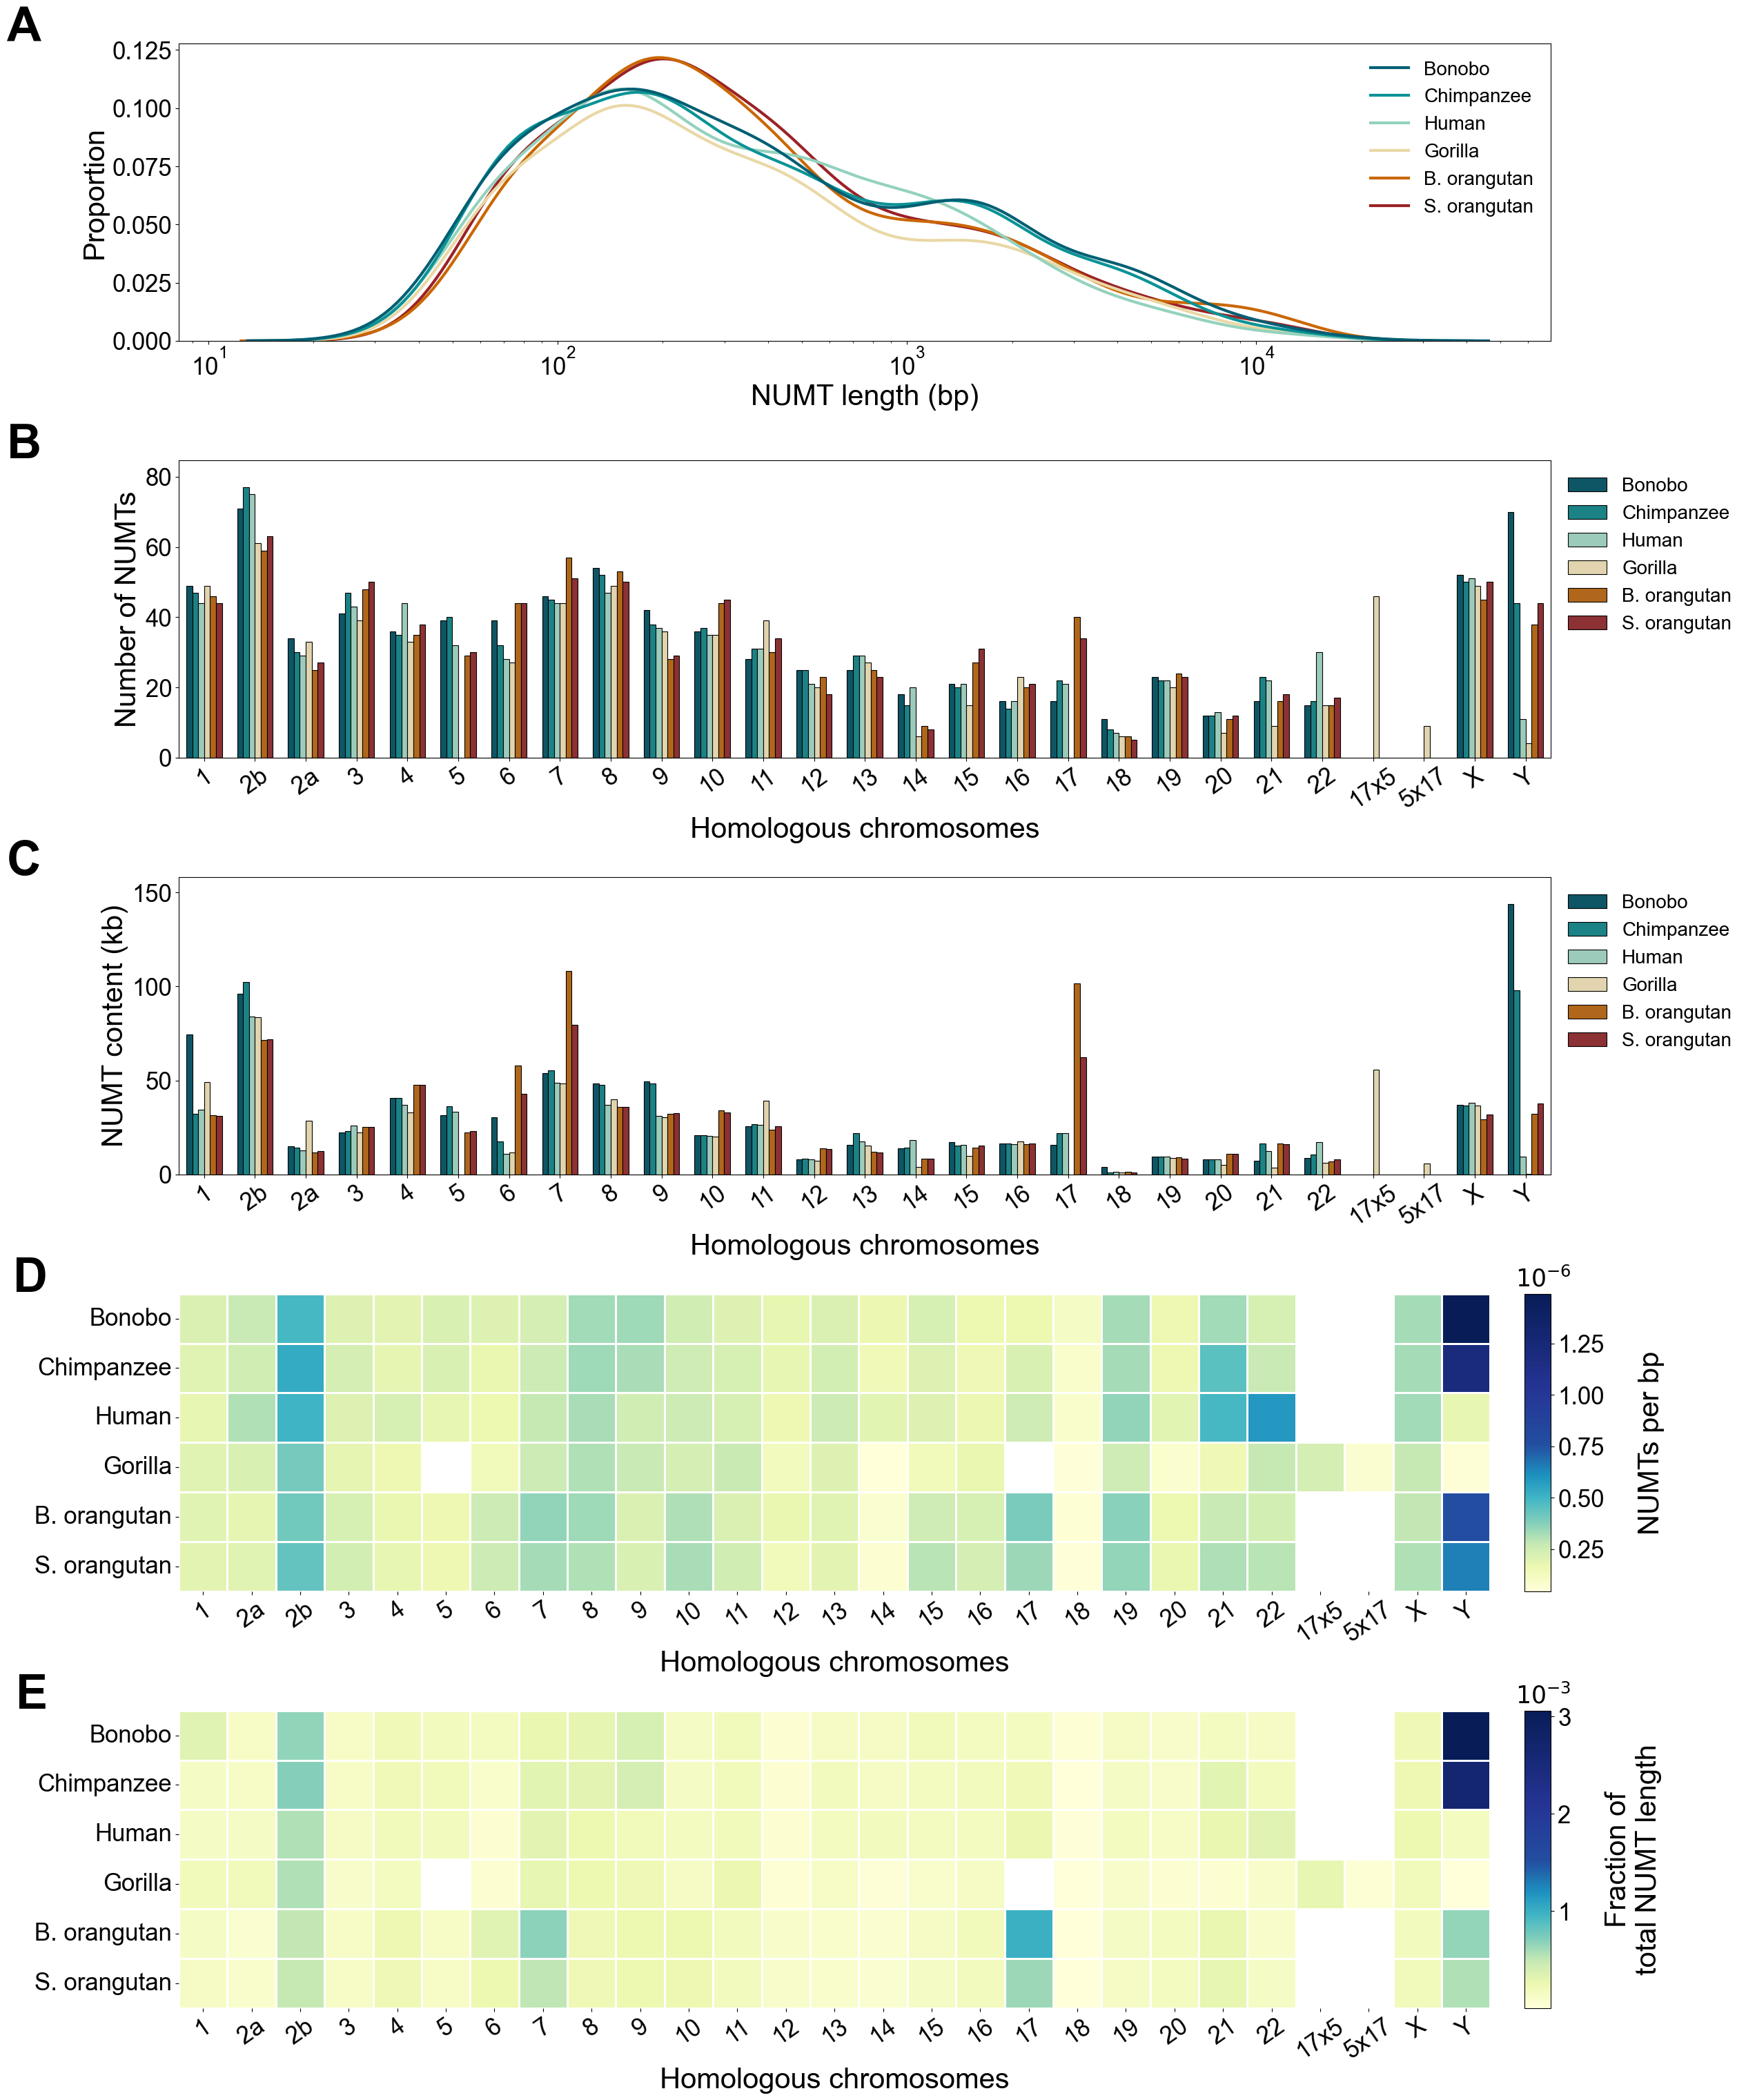

Species
B. orangutan    257.0
Bonobo          285.0
Chimpanzee      280.0
Gorilla         264.0
S. orangutan    269.0
Siamang         264.0
Name: NUMT_Length, dtype: float64


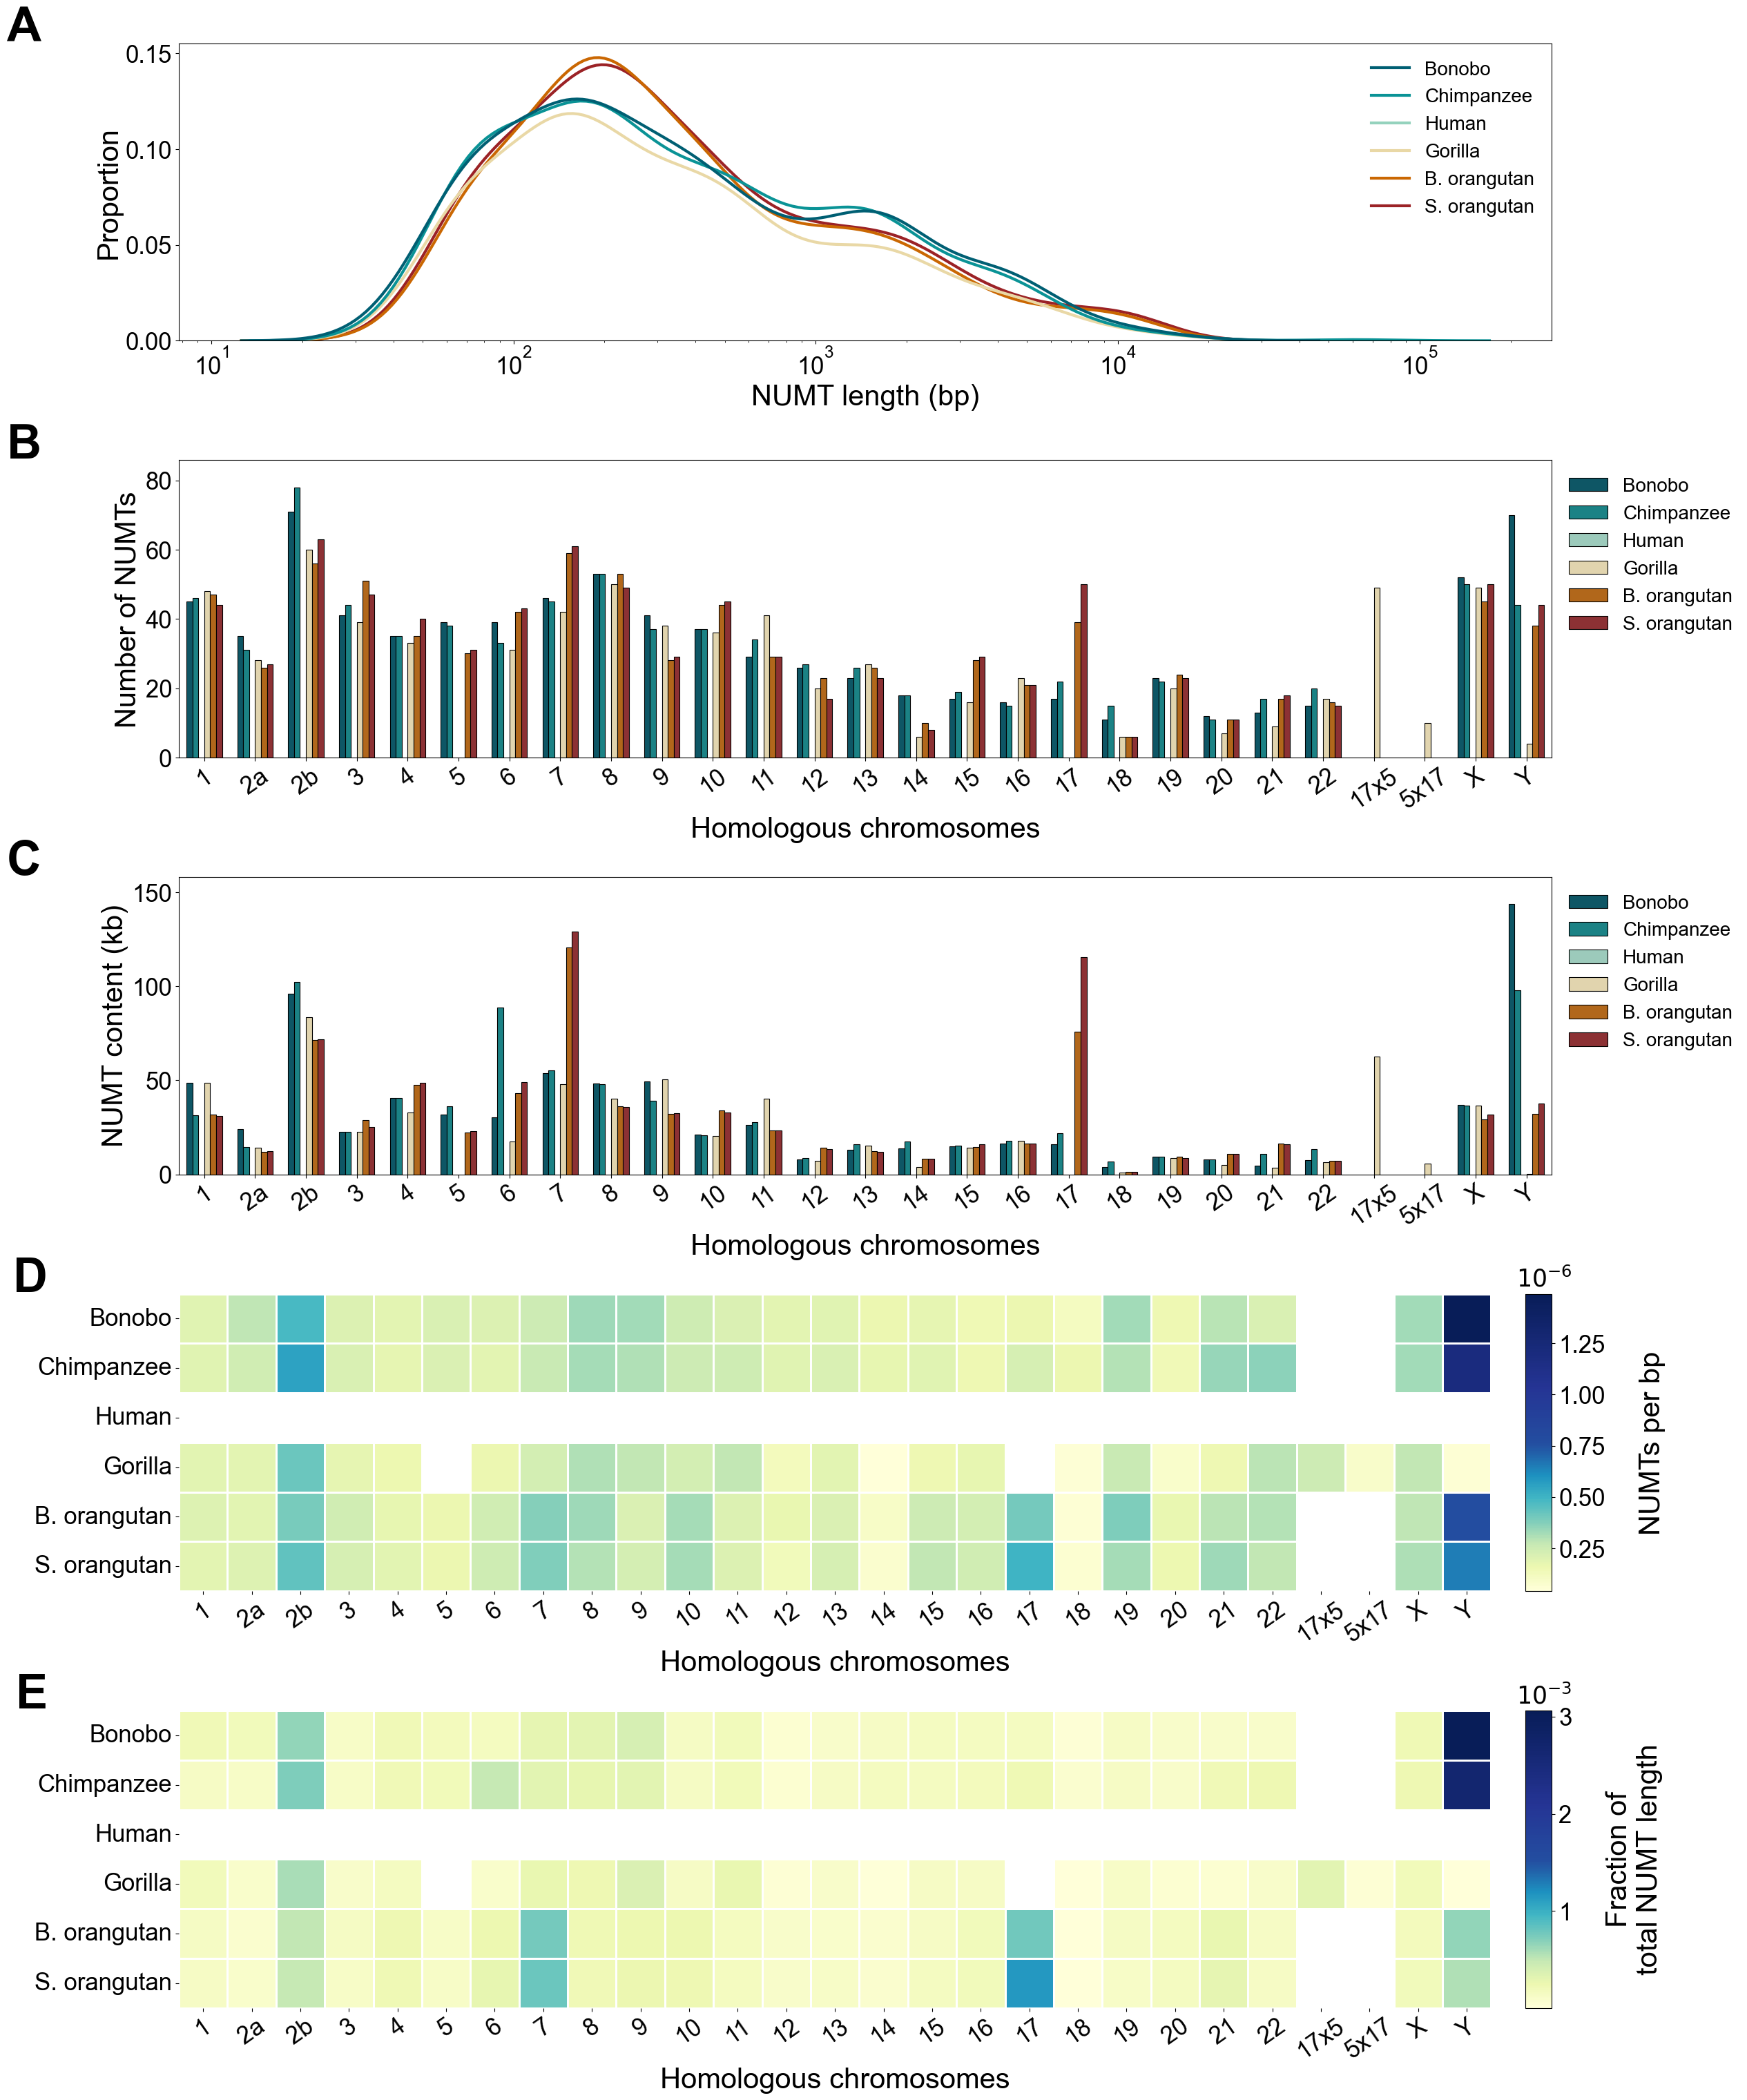

In [24]:
def run_sublots(haplotype="pri", sex=False):
    # NUMTs for primary or alt haplotypes.
    numts = get_numts(haplotype, sex=sex)
    if sex == True and haplotype == "alt":
        pri_numts = get_numts(haplotype="pri", sex=True)
        xy_numts = pri_numts[(pri_numts['Chrom'].str.contains('X'))|(pri_numts['Chrom'].str.contains('Y'))]
        xy_numts = xy_numts[xy_numts['Species']!='Human']
        numts = pd.concat( [numts, xy_numts] )

    # Remove chrX and chrY if haplotype is "alt"
    if haplotype == "alt":
        numts = numts[numts['Species'] != 'Human']

    numts_summary = compute_total_numt_bp_by_chr(df_in=numts) 

    # Create the figure and axes for subplots
    fig, axs = plt.subplots(5, 1, figsize=(25, 30))
    # fig, axs = plt.subplots(5, 1, figsize=(8.27, 11.69) ) #A4 format

    # Adjust spacing
    # plt.subplots_adjust(hspace=0.5, wspace=0.3)  # Increase hspace and wspace as needed
    plt.subplots_adjust(left=0.35, hspace=0.5, wspace=0.3)  # Increase left space

    # Font sizes.
    font_sizes = {
        'tick_label':25, 'axis_label':30, 'legend':20, 'title':30, 'rotation_axis_label':35
    }
    # font_sizes = {
    #     'tick_label':10, 'axis_label':14, 'legend':8, 'rotation_axis_label':40
    # }


    # Generate each plot by calling the corresponding function
    plot_lengths(df_in=numts, ax=axs[0], font_sizes=font_sizes)
    plot_by_chr(numts_summary, y_column='NUMT_Counts', ax=axs[1], font_sizes=font_sizes)
    plot_by_chr(numts_summary, y_column='Total_bp', ax=axs[2], font_sizes=font_sizes)
    plot_density_heat(df_in=numts_summary, data_column='Density_of_events', skewed_cmap=True, show_values=False, ax=axs[3], font_sizes=font_sizes)
    plot_density_heat(df_in=numts_summary, data_column='Density_of_bp', skewed_cmap=True, show_values=False, ax=axs[4], font_sizes=font_sizes)

    # Adjust layout
    plt.tight_layout()

    # Add labels A, B, C, D, E to the upper left of each subplot
    labels = ['A', 'B', 'C', 'D', 'E']
    for i, ax in enumerate(axs.flat):
        ax.text(-0.1, 1.05, labels[i], transform=ax.transAxes, fontsize=50, fontweight='bold', va='center', ha='right')

    # Export.
    if haplotype == "pri":
        plt.savefig( f"plots/{haplotype}/multiplot_fig1_section1.png", bbox_inches='tight')  #, dpi=300)
        plt.savefig( f"plots/{haplotype}/multiplot_fig1_section1.pdf", bbox_inches='tight')  #, dpi=300)
    elif haplotype == "alt":
        plt.savefig( f"plots/{haplotype}/multiplot_figS1_section1_alt.png", bbox_inches='tight')  #, dpi=300)
        plt.savefig( f"plots/{haplotype}/multiplot_figS1_section1_alt.pdf", bbox_inches='tight')  #, dpi=300)

    plt.show()


run_sublots(haplotype="pri", sex=True)
run_sublots(haplotype="alt", sex=True)

In [25]:
print('Summary Stats of NUMT Lengths')
get_numts().groupby(['Species'])['NUMT_Length'].describe()

Summary Stats of NUMT Lengths


,count,mean,std,min,25%,50%,75%,max
Species,,,,,,,,
Bonobo,713.0,887.277700,1761.800992,37.0,118.00,249.0,821.00,16162.0
Bornean orangutan,714.0,997.131653,1995.840840,34.0,138.25,264.5,782.25,12106.0
Chimpanzee,717.0,848.039052,1601.860869,37.0,119.00,252.0,849.00,14849.0
Gorilla,648.0,840.981481,1561.695502,43.0,126.75,265.5,756.00,14815.0
Human,711.0,769.776371,1427.440877,39.0,128.00,267.0,798.00,14836.0
Siamang,559.0,827.186047,1364.140183,39.0,123.50,266.0,762.00,14264.0
Sumatran orangutan,715.0,883.518881,1735.149108,42.0,134.50,266.0,696.00,12113.0
